<a href="https://colab.research.google.com/github/Krishnapatil28113/PICT_Coursework/blob/LP3_SEM7/ML_01_Uber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Predict the price of the Uber ride from a given pickup point to the agreed drop-off
# location.Perform following tasks:
# 1. Pre-process the dataset. --> Handling Missing Values, Feature Transformation
# 2. Identify outliers. --> Identifying outliers using seaborn, Removing the outliers
# 3. Check the correlation.
# 4. Implement linear regression and random forest regression models.
# Evaluate the models and compare their respective scores like R2, RMSE, etc.
# Dataset link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns

In [31]:
df = pd.read_csv('data.csv')
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [32]:
df.dtypes

,0
Unnamed: 0,int64
key,object
fare_amount,float64
pickup_datetime,object
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64


In [33]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [34]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


# Preprocessing

Handle Missing Values

In [35]:
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [36]:
df['dropoff_longitude'].fillna(value = df['dropoff_longitude'].mean(), inplace = True)

<ipython-input-36-147f5427000c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dropoff_longitude'].fillna(value = df['dropoff_longitude'].mean(), inplace = True)


In [37]:
df['dropoff_latitude'].fillna(value = df['dropoff_latitude'].median(), inplace = True)

<ipython-input-37-54b46352abef>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dropoff_latitude'].fillna(value = df['dropoff_latitude'].median(), inplace = True)


Feature Transformation

In [38]:
df = df.rename(columns = {'pickup_datetime' : 'pickup_time'})
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_time', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [50]:
df.drop(['Unnamed: 0', 'key'], axis = 1, inplace = True)
df.head()

,fare_amount,pickup_time,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,0.015140
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,0.022103
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,0.053109
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,0.016528
5,4.9,2011-02-12 02:27:09+00:00,-73.969019,40.755910,-73.969019,40.755910,1,0.000000


In [39]:
# In order to change the data type of a column to date_time, we can use the
# pandas function pd.to_datetime(ds['column_name'], errors = 'coerce') The
# 'to_datetime' function takes the name of the column whose datatype is to be
# changed to datetime and errors = 'corece' is used for error handling

In [51]:
df['pickup_time'] = pd.to_datetime(df['pickup_time'], errors = 'coerce')
df.dtypes

,0
fare_amount,float64
pickup_time,"datetime64[ns, UTC]"
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64
distance,float64


In [52]:
df.head()

,fare_amount,pickup_time,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,0.015140
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,0.022103
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,0.053109
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,0.016528
5,4.9,2011-02-12 02:27:09+00:00,-73.969019,40.755910,-73.969019,40.755910,1,0.000000


In [53]:
# Calculating the distance between the start and end point in order to calculate the price

def euclidean_distance(lat1, long1, lat2, long2):
    dlat = lat2 - lat1
    dlong = long2 - long1
    distance = np.sqrt(dlat**2 + dlong**2)
    return distance

df['distance'] = df.apply(
    lambda row : euclidean_distance(row['pickup_latitude'], row['pickup_longitude'], row['dropoff_latitude'], row['dropoff_longitude']),
    axis = 1,
)

# Analysis

Outlier Analysis

<Axes: ylabel='fare_amount'>

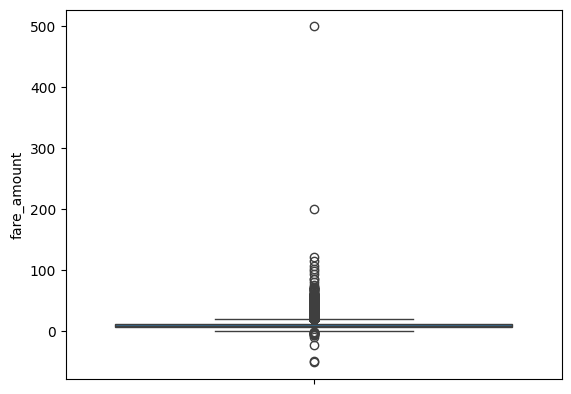

In [54]:
sns.boxplot(df['fare_amount'])

<Axes: xlabel='passenger_count', ylabel='fare_amount'>

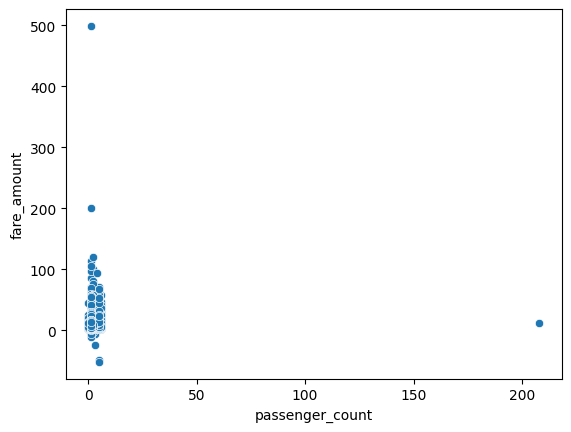

In [55]:
sns.scatterplot(df, x='passenger_count', y='fare_amount')

Removing Outliers

<Axes: xlabel='passenger_count', ylabel='fare_amount'>

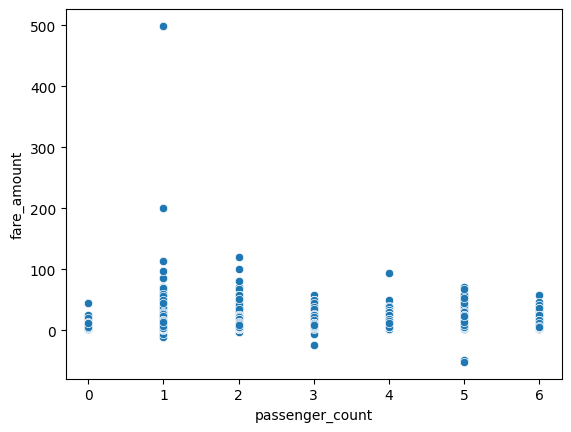

In [56]:
def remove_outliers(feature):
    global df
    q3, q1 = np.percentile(df[feature], [75, 25])
    iqr = q3 - q1
    df = df[(df[feature] >= q1 - 1.5*iqr) & (df[feature] <= q3 + 1.5*iqr)]


remove_outliers('pickup_latitude')
remove_outliers('pickup_longitude')
remove_outliers('dropoff_latitude')
remove_outliers('dropoff_longitude')

sns.scatterplot(data = df, x = 'passenger_count', y = 'fare_amount')

<Axes: ylabel='pickup_latitude'>

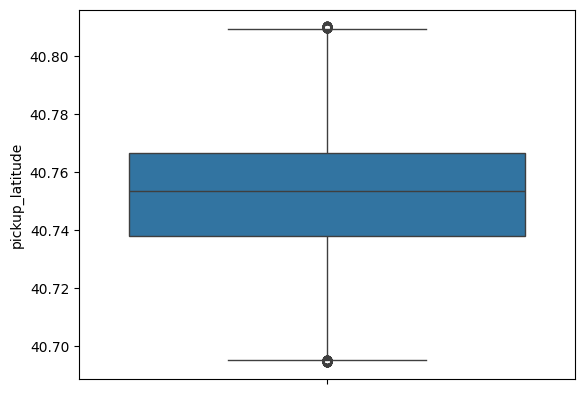

In [57]:
sns.boxplot(data = df['pickup_latitude'])

# Linear Regression

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into features and target (which is to be predicted, i.e fare amount)
x = df.drop('fare_amount', axis = 1)
y = df['fare_amount']

x['pickup_time'] = pd.to_datetime(df['pickup_time'], errors = 'coerce')
x['pickup_hour'] = x['pickup_time'].dt.hour
x['pickup_dayofweek'] = x['pickup_time'].dt.dayofweek

x = x.drop('pickup_time', axis = 1)

# Split the dataset into training and testing data using train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [64]:
x.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance,pickup_hour,pickup_dayofweek
0,-73.999817,40.738354,-73.999512,40.723217,1,0.015140,19,3
1,-73.994355,40.728225,-73.994710,40.750325,1,0.022103,20,4
2,-74.005043,40.740770,-73.962565,40.772647,1,0.053109,21,0
3,-73.976124,40.790844,-73.965316,40.803349,3,0.016528,8,4
5,-73.969019,40.755910,-73.969019,40.755910,1,0.000000,2,5


In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create an instance of the Linear Regression Model
model = LinearRegression()
model.fit(x_train_scaled, y_train)

# Now test the model and then store the result in 'y_pred' for later comparison
y_pred = model.predict(x_test_scaled)

In [66]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

print("r2 score: ", r2_score(y_test, y_pred))
print("Root Mean Squared Error: ", root_mean_squared_error(y_test, y_pred))

r2 score:  0.5305858032681747
Root Mean Squared Error:  3.2331161484833597


# Random Forest Regression

In [67]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

In [68]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

print("r2_score: ", r2_score(y_test, y_pred))
print("Root Mean Squared Error: ", root_mean_squared_error(y_test, y_pred))

r2_score:  0.5655087028920929
Root Mean Squared Error:  3.1105252970716104
